<a href="https://colab.research.google.com/github/AntoinePERRETTE/ETRS923-IA-et-Objets-Connect-s/blob/main/ETRS923.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/AntoinePERRETTE/ETRS923-IA-et-Objets-Connect-s

Cloning into 'ETRS923-IA-et-Objets-Connect-s'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 29 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 1.27 MiB | 4.04 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
# Add the path for the Python code for your project folder
import sys
sys.path.append('/content/ETRS923-IA-et-Objets-Connect-s/TP_1')

In [ ]:
# Connect the Matplotlib library to visualize images in the model from the your folder
from IPython.display import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans']
matplotlib.rcParams['text.usetex'] = False

#**TP 1 : Problème MNIST**
##a - Réseau simple de deux couches avec la fonction d'activation softmax :

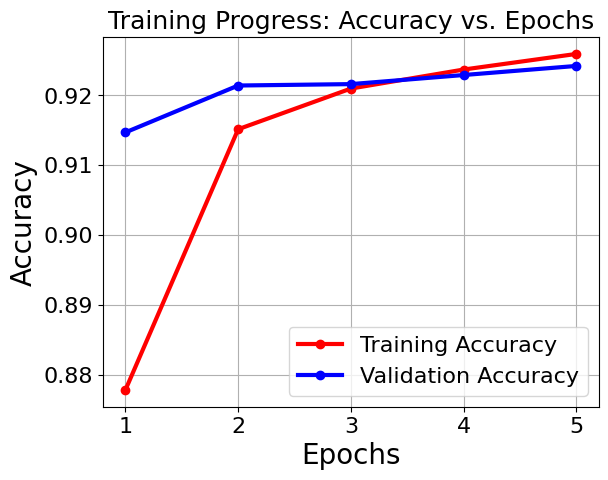

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9259 - loss: 0.2670 - val_accuracy: 0.9242 - val_loss: 0.2710
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2710
Test accuracy: 0.9242

--- Model Summary (Neurons and Synapses) ---
Layer: dense_5 (Dense), Parameters: 7850, Neurons: 10, Weights: 7840, Bias: 10, Calculated Synapses (Weights + Bias): 7850

Total Neurons (approx, mainly from Dense/RNN): 10
Total Synapses (Total Trainable Parameters): 7850


In [ ]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple softmax classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='softmax', input_shape=(784,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

##b - Réseau de deux couches cachés, et ReLu comme fonction d'activation :

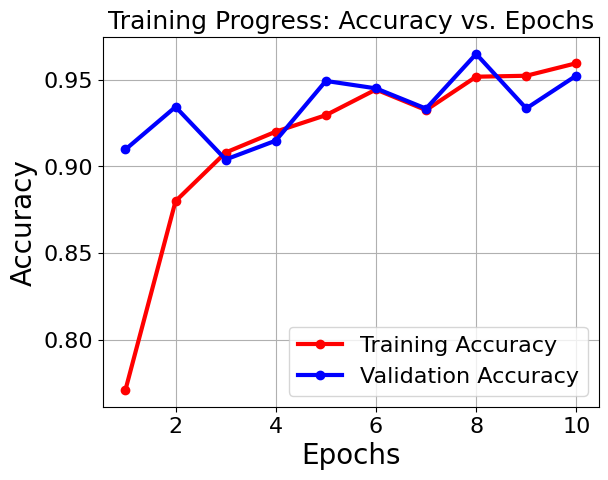

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9596 - loss: nan - val_accuracy: 0.9525 - val_loss: 0.2636
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9525 - loss: 0.2636
Test accuracy: 0.9525

--- Model Summary (Neurons and Synapses) ---
Layer: dense_14 (Dense), Parameters: 307720, Neurons: 392, Weights: 307328, Bias: 392, Calculated Synapses (Weights + Bias): 307720
Layer: dense_15 (Dense), Parameters: 77028, Neurons: 196, Weights: 76832, Bias: 196, Calculated Synapses (Weights + Bias): 77028
Layer: dense_16 (Dense), Parameters: 19306, Neurons: 98, Weights: 19208, Bias: 98, Calculated Synapses (Weights + Bias): 19306
Layer: dense_17 (Dense), Parameters: 990, Neurons: 10, Weights: 980, Bias: 10, Calculated Synapses (Weights + Bias): 990

Total Neurons (approx, mainly from Dense/RNN): 696
Total Synapses (Total Trainable Parameters): 405044


In [14]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple softmax classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(392, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(196, activation='relu', input_shape=(392,)),
    tf.keras.layers.Dense(98, activation='relu', input_shape=(196,)),
    tf.keras.layers.Dense(10, activation='relu', input_shape=(98,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

##c - Réseau de deux couches cachés, et tanh comme fonction d'activation :

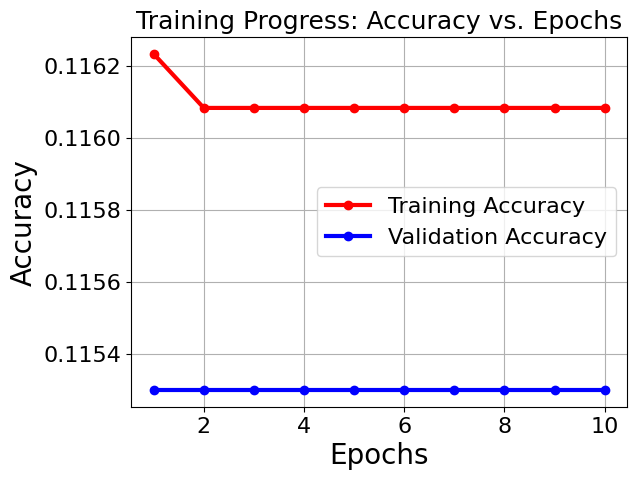

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1161 - loss: 8.0614 - val_accuracy: 0.1153 - val_loss: 8.0188
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1153 - loss: 8.0188
Test accuracy: 0.1153

--- Model Summary (Neurons and Synapses) ---
Layer: dense_18 (Dense), Parameters: 307720, Neurons: 392, Weights: 307328, Bias: 392, Calculated Synapses (Weights + Bias): 307720
Layer: dense_19 (Dense), Parameters: 77028, Neurons: 196, Weights: 76832, Bias: 196, Calculated Synapses (Weights + Bias): 77028
Layer: dense_20 (Dense), Parameters: 19306, Neurons: 98, Weights: 19208, Bias: 98, Calculated Synapses (Weights + Bias): 19306
Layer: dense_21 (Dense), Parameters: 990, Neurons: 10, Weights: 980, Bias: 10, Calculated Synapses (Weights + Bias): 990

Total Neurons (approx, mainly from Dense/RNN): 696
Total Synapses (Total Trainable Parameters): 405044


In [15]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple tanh classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(392, activation='tanh', input_shape=(784,)),
    tf.keras.layers.Dense(196, activation='tanh', input_shape=(392,)),
    tf.keras.layers.Dense(98, activation='tanh', input_shape=(196,)),
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(98,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

##d - Réseau de deux couches cachés, et sigmoid comme fonction d'activation :

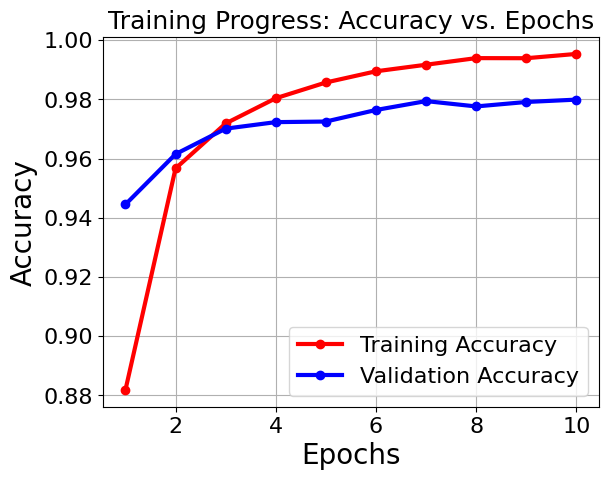

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9953 - loss: 0.0144 - val_accuracy: 0.9799 - val_loss: 0.0824
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9799 - loss: 0.0824
Test accuracy: 0.9799

--- Model Summary (Neurons and Synapses) ---
Layer: dense_22 (Dense), Parameters: 307720, Neurons: 392, Weights: 307328, Bias: 392, Calculated Synapses (Weights + Bias): 307720
Layer: dense_23 (Dense), Parameters: 77028, Neurons: 196, Weights: 76832, Bias: 196, Calculated Synapses (Weights + Bias): 77028
Layer: dense_24 (Dense), Parameters: 19306, Neurons: 98, Weights: 19208, Bias: 98, Calculated Synapses (Weights + Bias): 19306
Layer: dense_25 (Dense), Parameters: 990, Neurons: 10, Weights: 980, Bias: 10, Calculated Synapses (Weights + Bias): 990

Total Neurons (approx, mainly from Dense/RNN): 696
Total Synapses (Total Trainable Parameters): 405044


In [16]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(20)
tf.random.set_seed(20)
random.seed(20)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple sigmoid classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(392, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(196, activation='sigmoid', input_shape=(392,)),
    tf.keras.layers.Dense(98, activation='sigmoid', input_shape=(196,)),
    tf.keras.layers.Dense(10, activation='sigmoid', input_shape=(98,)),
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)